In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import scienceplots  # noqa: F401
import torch
from edl_losses.edl import EDLLoss, edl_inference
from edl_losses.gen import GENLoss, gen_inference

from csi_vae.jobs import JobSettings, dataset, fusion, vae
from csi_vae.jobs.job import make_dataloader

plt.style.use(["science", "no-latex", "bright"])
plt.rcParams.update({"figure.dpi": 300})

settings = JobSettings()

LAUNCH_DIR = Path("../out/flat_conv_full")
WEIGHTS_DIR = Path("../weights")
PLOTS_DIR = LAUNCH_DIR / "plots"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OOD_DATASET = Path("../dataset/S1b.h5")

PLOTS_DIR.mkdir(exist_ok=True)

/mnt/servicesdata/lcotti/csi-vae/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
studies_files = sorted([f.name for f in LAUNCH_DIR.iterdir() if f.is_file() and f.suffix == ".sqlite"])
studies = [
    optuna.load_study(study_name=study.split(".")[0], storage=f"sqlite:///{LAUNCH_DIR / study}").trials_dataframe()
    for study in studies_files
]

best_models_per_study: list[dict] = []

for i, study in enumerate(studies):
    completed = study[study["state"] == "COMPLETE"].copy()
    study_best= {
        "n_gaussians": i + 1,
        "trial_number": 0,
        "trial_value": 0.0,
        "seed": 0,
        "best_seed_accuracy": 0.0,
        "params": {},
    }

    for _, trial in completed.iterrows():
        accuracies_per_seed = trial["user_attrs_accuracies"]

        best_seed = max(accuracies_per_seed, key=accuracies_per_seed.get)
        best_accuracy = float(accuracies_per_seed[str(best_seed)])

        if trial["value"] > study_best["trial_value"]:
            study_best = {
                "n_gaussians": i + 1,
                "trial_number": trial["number"],
                "trial_value": trial["value"],
                "seed": int(best_seed),
                "best_seed_accuracy": best_accuracy,
                "params": trial.filter(like="params_").rename(lambda x: x.replace("params_", "")).to_dict(),
            }

    best_models_per_study.append(study_best)

best_model = max(best_models_per_study, key=lambda x: x["best_seed_accuracy"])
print(
    f"Best model: n_gaussians={best_model['n_gaussians']}, "
    f"trial_number={best_model['trial_number']}, "
    f"seed={best_model['seed']}, "
    f"accuracy={best_model['best_seed_accuracy']:.4f}",
)

Best model: n_gaussians=2, trial_number=77, seed=347227206, accuracy=0.9812


In [ ]:
batch_size = 2**best_model["params"]["batch_size_exp"]
train_ds, val_ds, test_ds = dataset.load(
    dataset_path=Path("../") / settings.dataset_path,
    window_size=settings.window_size,
    n_activities=settings.n_activities,
    stride=settings.stride,
)
train_dl = make_dataloader(train_ds, batch_size=batch_size, shuffle=True, seed=best_model["seed"])
val_dl = make_dataloader(val_ds, batch_size=batch_size, shuffle=False, seed=best_model["seed"])
test_dl = make_dataloader(test_ds, batch_size=batch_size, shuffle=False, seed=best_model["seed"])

ood_train_ds, ood_val_ds, ood_test_ds = dataset.load(
    dataset_path=OOD_DATASET,
    window_size=settings.window_size,
    n_activities=settings.n_activities,
    stride=settings.stride,
)
ood_ds = torch.utils.data.ConcatDataset([ood_train_ds, ood_val_ds, ood_test_ds])
ood_dl = make_dataloader(ood_ds, batch_size=batch_size, shuffle=False, seed=best_model["seed"])

In [4]:
gaussians = [
    vae.SingleAntenna(
        settings.window_size,
        settings.n_subcarriers,
        best_model["n_gaussians"],
        vae.CONV_SPECS[best_model["params"]["conv_layers_spec"]],
    ).to(DEVICE)
    for _ in range(settings.n_antennas)
]
delayed_fusion = fusion.Delayed(
    gaussians,
    best_model["n_gaussians"],
    settings.n_activities,
    best_model["params"]["n_fusion_layers"],
    best_model["params"]["fusion_dropout"],
).to(DEVICE)

model_path = (
    WEIGHTS_DIR
    / f"l{best_model['n_gaussians']}"
    / f"t{best_model['trial_number']}"
    / f"s{best_model['seed']}"
    / "delayed_fusion.pt"
)
delayed_fusion.load_state_dict(torch.load(model_path))

<All keys matched successfully>

## EDL (Sansoy et al., 2018)

In [5]:
edl_fusion = fusion.Delayed(
    gaussians,
    best_model["n_gaussians"],
    settings.n_activities,
    best_model["params"]["n_fusion_layers"],
    best_model["params"]["fusion_dropout"],
)


class _EDLTrainer(fusion.Trainer):
    def __init__(
        self,
        model: fusion.Delayed,
        train_dl: torch.utils.data.DataLoader,
        val_dl: torch.utils.data.DataLoader,
        params: fusion.TrainerParams,
        device: torch.device | None = None,
    ) -> None:
        super().__init__(model, train_dl, val_dl, params, device)
        self._current_epoch = 0
        edl_loss = EDLLoss(annealing_epochs=10)
        self._criterion = lambda logits, y: edl_loss(logits, y, self._current_epoch)

    def _run_batch(self, x: torch.Tensor, y: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        self._optimizer.zero_grad()

        with torch.autocast(device_type=self._device.type, dtype=torch.float16):
            logits = self._model(x)

        logits = torch.nn.functional.softplus(logits)
        loss = self._criterion(logits, y)
        self._scaler.scale(loss).backward()
        self._scaler.step(self._optimizer)
        self._scaler.update()

        class_indices, _, _ = edl_inference(logits)
        accuracy = (class_indices == y).float().mean()

        return loss.detach(), accuracy

    def _run_epoch(self) -> tuple[torch.Tensor, torch.Tensor]:
        self._current_epoch += 1
        return super()._run_epoch()


# Train classification head with EDL loss
edl_trainer = _EDLTrainer(
    edl_fusion,
    train_dl,
    val_dl,
    fusion.TrainerParams(
        lr=best_model["params"]["lr"],
        early_stop_patience=settings.early_stop_patience,
        early_stop_warmup_epochs=settings.early_stop_warmup_epochs,
    ),
    device=DEVICE,
)
edl_trainer.train(settings.n_epochs)

(0.49668392539024353, 0.7875937819480896)

In [6]:
# Inference
edl_fusion.eval()

correct = total = 0
mean_uncertainty_correct = mean_uncertainty_wrong = mean_p_hat_correct = mean_p_hat_wrong = 0
n_correct = n_wrong = 0

with torch.no_grad():
    for x, y in test_dl:
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16):
            model_results = edl_fusion(x.to(DEVICE))

        if not isinstance(model_results, tuple):
            model_results = (model_results,)
        pred, uncertainty, p_hat = edl_inference(*model_results)

        mask_correct = pred == y.to(DEVICE)
        mask_wrong = ~mask_correct

        correct += mask_correct.sum().item()
        total += y.to(DEVICE).size(0)
        mean_uncertainty_correct += uncertainty[mask_correct].sum().item()
        mean_uncertainty_wrong += uncertainty[mask_wrong].sum().item()
        mean_p_hat_correct += p_hat[mask_correct, pred[mask_correct]].sum().item()
        mean_p_hat_wrong += p_hat[mask_wrong, pred[mask_wrong]].sum().item()
        n_correct += mask_correct.sum().item()
        n_wrong += mask_wrong.sum().item()

print(f"\nTest accuracy: {correct / total:.4f}")
print(f"Mean uncertainty — correct: {mean_uncertainty_correct / max(n_correct, 1):.4f}")
print(f"Mean uncertainty — wrong: {mean_uncertainty_wrong / max(n_wrong, 1):.4f}")
print(f"Mean p_hat — correct: {mean_p_hat_correct / max(n_correct, 1):.4f}")
print(f"Mean p_hat — wrong: {mean_p_hat_wrong / max(n_wrong, 1):.4f}")


Test accuracy: 0.8438
Mean uncertainty — correct: 0.4058
Mean uncertainty — wrong: 0.9967
Mean p_hat — correct: 0.6275
Mean p_hat — wrong: 0.0864


## GEN (Sansoy et al., 2020)

In [7]:
@torch.no_grad()
def generate_ood_samples(
    gaussians: list[vae.SingleAntenna],
    x: torch.Tensor,
    noise_scale: float = 0.3,
) -> torch.Tensor:
    """Generate OOD samples by perturbing in the latent space of each antenna VAE.

    This is the simplified version of the VAE+GAN generator from the GEN paper —
    perturb z ~ q(z|x) by adding Gaussian noise, then decode.

    Arguments:
        gaussians: list of SingleAntenna VAE modules, one per antenna.
        x: input tensor of shape (B, n_antennas, window_size, n_subcarriers)
        noise_scale: std of the latent perturbation.

    Returns:
        Tensor of shape (B, n_antennas, window_size, n_subcarriers) containing the OOD samples.

    """
    ood_list = []

    for i, vae_antenna in enumerate(gaussians):
        mu, logvar = vae_antenna.encode(x[:, i])
        z = mu + torch.exp(0.5 * logvar) * torch.randn_like(logvar)  # sample z
        z_ood = z + noise_scale * torch.randn_like(z)  # perturb
        x_ood = vae_antenna.decode(z_ood)
        ood_list.append(x_ood)

    return torch.stack(ood_list, dim=1)  # (B, n_antennas, window_size, n_subcarriers)

In [8]:
class _GENTrainer(fusion.Trainer):
    def __init__(
        self,
        model: fusion.Delayed,
        train_dl: torch.utils.data.DataLoader,
        val_dl: torch.utils.data.DataLoader,
        params: fusion.TrainerParams,
        device: torch.device | None = None,
    ) -> None:
        super().__init__(model, train_dl, val_dl, params, device)
        self._current_epoch = 0
        self._criterion = GENLoss()

    def _run_batch(self, x: torch.Tensor, y: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        self._optimizer.zero_grad()

        with torch.autocast(device_type=self._device.type, dtype=torch.float16):
            x_ood_list = generate_ood_samples(gaussians, x)
            logits_in = self._model(x)
            logits_out = self._model(x_ood_list)

        loss = self._criterion(logits_in, logits_out, y)
        self._scaler.scale(loss).backward()
        self._scaler.step(self._optimizer)
        self._scaler.update()

        class_indices, _, _ = gen_inference(logits_in)
        accuracy = (class_indices == y).float().mean()

        return loss.detach(), accuracy

    @torch.no_grad()
    def _run_val_epoch(self) -> torch.Tensor:
        self._model.eval()

        total_loss = torch.tensor(0.0, device=self._device)

        for x_cpu, y_cpu in self._val_dl:
            x, y = x_cpu.to(self._device, non_blocking=True), y_cpu.to(self._device, non_blocking=True)

            with torch.autocast(device_type=self._device.type, dtype=torch.float16):
                x_ood_list = generate_ood_samples(gaussians, x)
                logits_in = self._model(x)
                logits_out = self._model(x_ood_list)

            loss = self._criterion(logits_in, logits_out, y)
            total_loss += loss.detach()

        return total_loss / self._len_val


gen_fusion = fusion.Delayed(
    gaussians,
    best_model["n_gaussians"],
    settings.n_activities,
    best_model["params"]["n_fusion_layers"],
    best_model["params"]["fusion_dropout"],
).to(DEVICE)

# Train classification head with EDL loss
gen_trainer = _GENTrainer(
    gen_fusion,
    train_dl,
    val_dl,
    fusion.TrainerParams(
        lr=best_model["params"]["lr"],
        early_stop_patience=settings.early_stop_patience,
        early_stop_warmup_epochs=settings.early_stop_warmup_epochs,
    ),
    device=DEVICE,
)

# Note: the accuracy returned here will be wrong, because the trainer is not using EDL inference
gen_trainer.train(settings.n_epochs)


(0.5744345188140869, 0.9194151759147644)

In [9]:
gen_fusion.eval()
correct = total = 0
mean_uncertainty_correct = mean_uncertainty_wrong = mean_p_hat_correct = mean_p_hat_wrong = 0
n_correct = n_wrong = 0

with torch.no_grad():
    for x, y in test_dl:
        labels = y.to(DEVICE)

        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16):
            logits = gen_fusion(x.to(DEVICE))

        pred, uncertainty, p_hat = gen_inference(logits)  # GEN uses same inference as EDL

        mask_correct = pred == labels
        mask_wrong = ~mask_correct

        correct += mask_correct.sum().item()
        total += labels.size(0)
        mean_uncertainty_correct += uncertainty[mask_correct].sum().item()
        mean_uncertainty_wrong += uncertainty[mask_wrong].sum().item()
        mean_p_hat_correct += p_hat[mask_correct, pred[mask_correct]].sum().item()
        mean_p_hat_wrong += p_hat[mask_wrong, pred[mask_wrong]].sum().item()
        n_correct += mask_correct.sum().item()
        n_wrong += mask_wrong.sum().item()

print(f"Test accuracy: {correct / total:.4f}")
print(f"Mean uncertainty — correct: {mean_uncertainty_correct / max(n_correct, 1):.4f}")
print(f"Mean uncertainty — wrong:   {mean_uncertainty_wrong / max(n_wrong, 1):.4f}")
print(f"Mean p_hat — correct: {mean_p_hat_correct / max(n_correct, 1):.4f}")
print(f"Mean p_hat — wrong:   {mean_p_hat_wrong / max(n_wrong, 1):.4f}")

Test accuracy: 0.9563
Mean uncertainty — correct: 0.5444
Mean uncertainty — wrong:   0.9092
Mean p_hat — correct: 0.4879
Mean p_hat — wrong:   0.1263


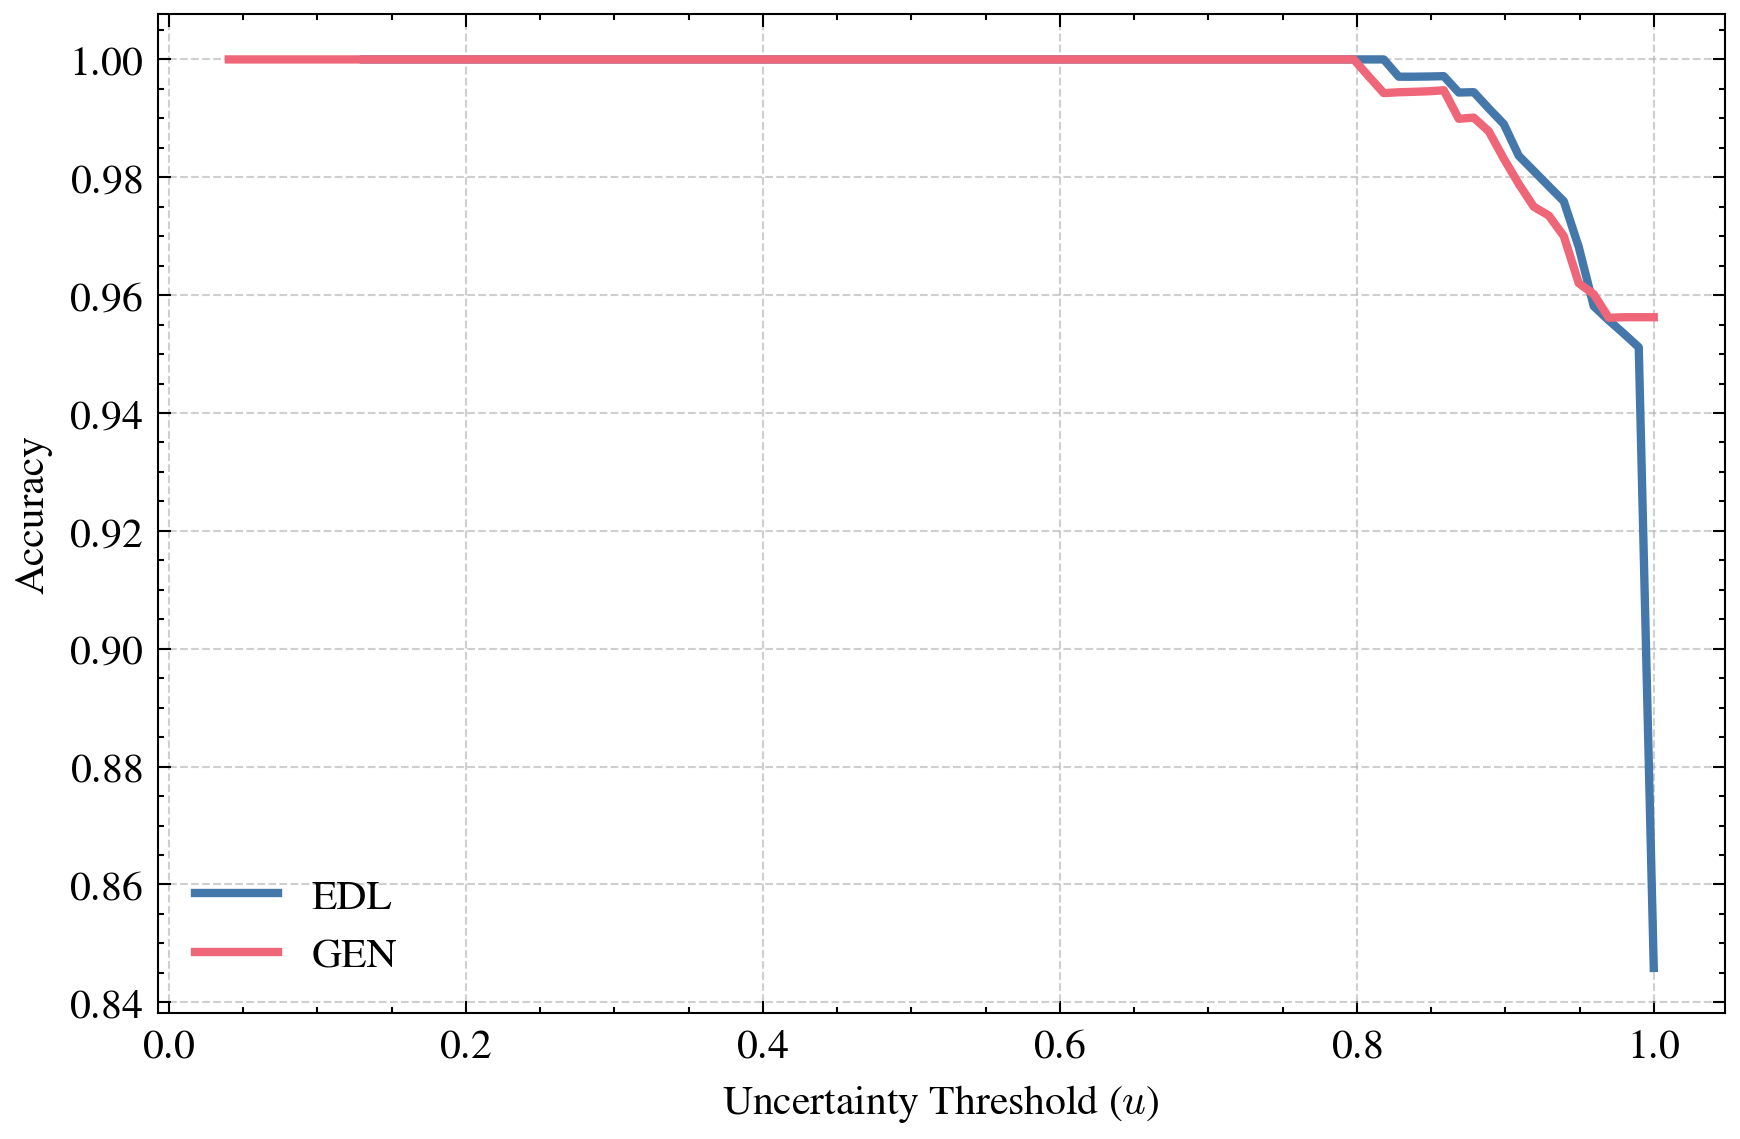

In [10]:
from collections.abc import Callable


def _accuracy_vs_uncertainty(
    model: torch.nn.Module,
    inference_fn: Callable,
    dataloader: torch.utils.data.DataLoader,
    device: torch.device,
) -> tuple[np.ndarray, list[float]]:
    model.eval()
    all_uncertainties = []
    all_correct = []

    with torch.no_grad():
        for x, y in dataloader:
            with torch.autocast(device_type=device.type, dtype=torch.float16):
                logits = model(x.to(device))

            # Using your edl_inference function
            pred, uncertainty, _ = inference_fn(logits)

            correct = (pred == y.to(device)).cpu().numpy()
            all_correct.extend(correct)
            all_uncertainties.extend(uncertainty.cpu().numpy())

    all_correct = np.array(all_correct)
    all_uncertainties = np.array(all_uncertainties)

    # Define thresholds (from 0.0 to 1.0)
    thresholds = np.linspace(0, 1, 100)
    accuracies = []

    for t in thresholds:
        mask = all_uncertainties <= t
        if np.any(mask):
            acc = np.mean(all_correct[mask])
            accuracies.append(acc)
        else:
            accuracies.append(None)

    return thresholds, accuracies


# Collect data
edl_thresholds, edl_accuracies = _accuracy_vs_uncertainty(edl_fusion, edl_inference, test_dl, DEVICE)
gen_thresholds, gen_accuracies = _accuracy_vs_uncertainty(gen_fusion, gen_inference, test_dl, DEVICE)

plt.figure(figsize=(6, 4))

# Accuracy Curve
plt.plot(edl_thresholds, edl_accuracies, lw=2, label="EDL")
plt.plot(gen_thresholds, gen_accuracies, lw=2, label="GEN")

plt.xlabel("Uncertainty Threshold ($u$)")
plt.ylabel("Accuracy")
plt.tick_params(axis="y")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "edl_accuracy_vs_uncertainty.pdf")
plt.show()

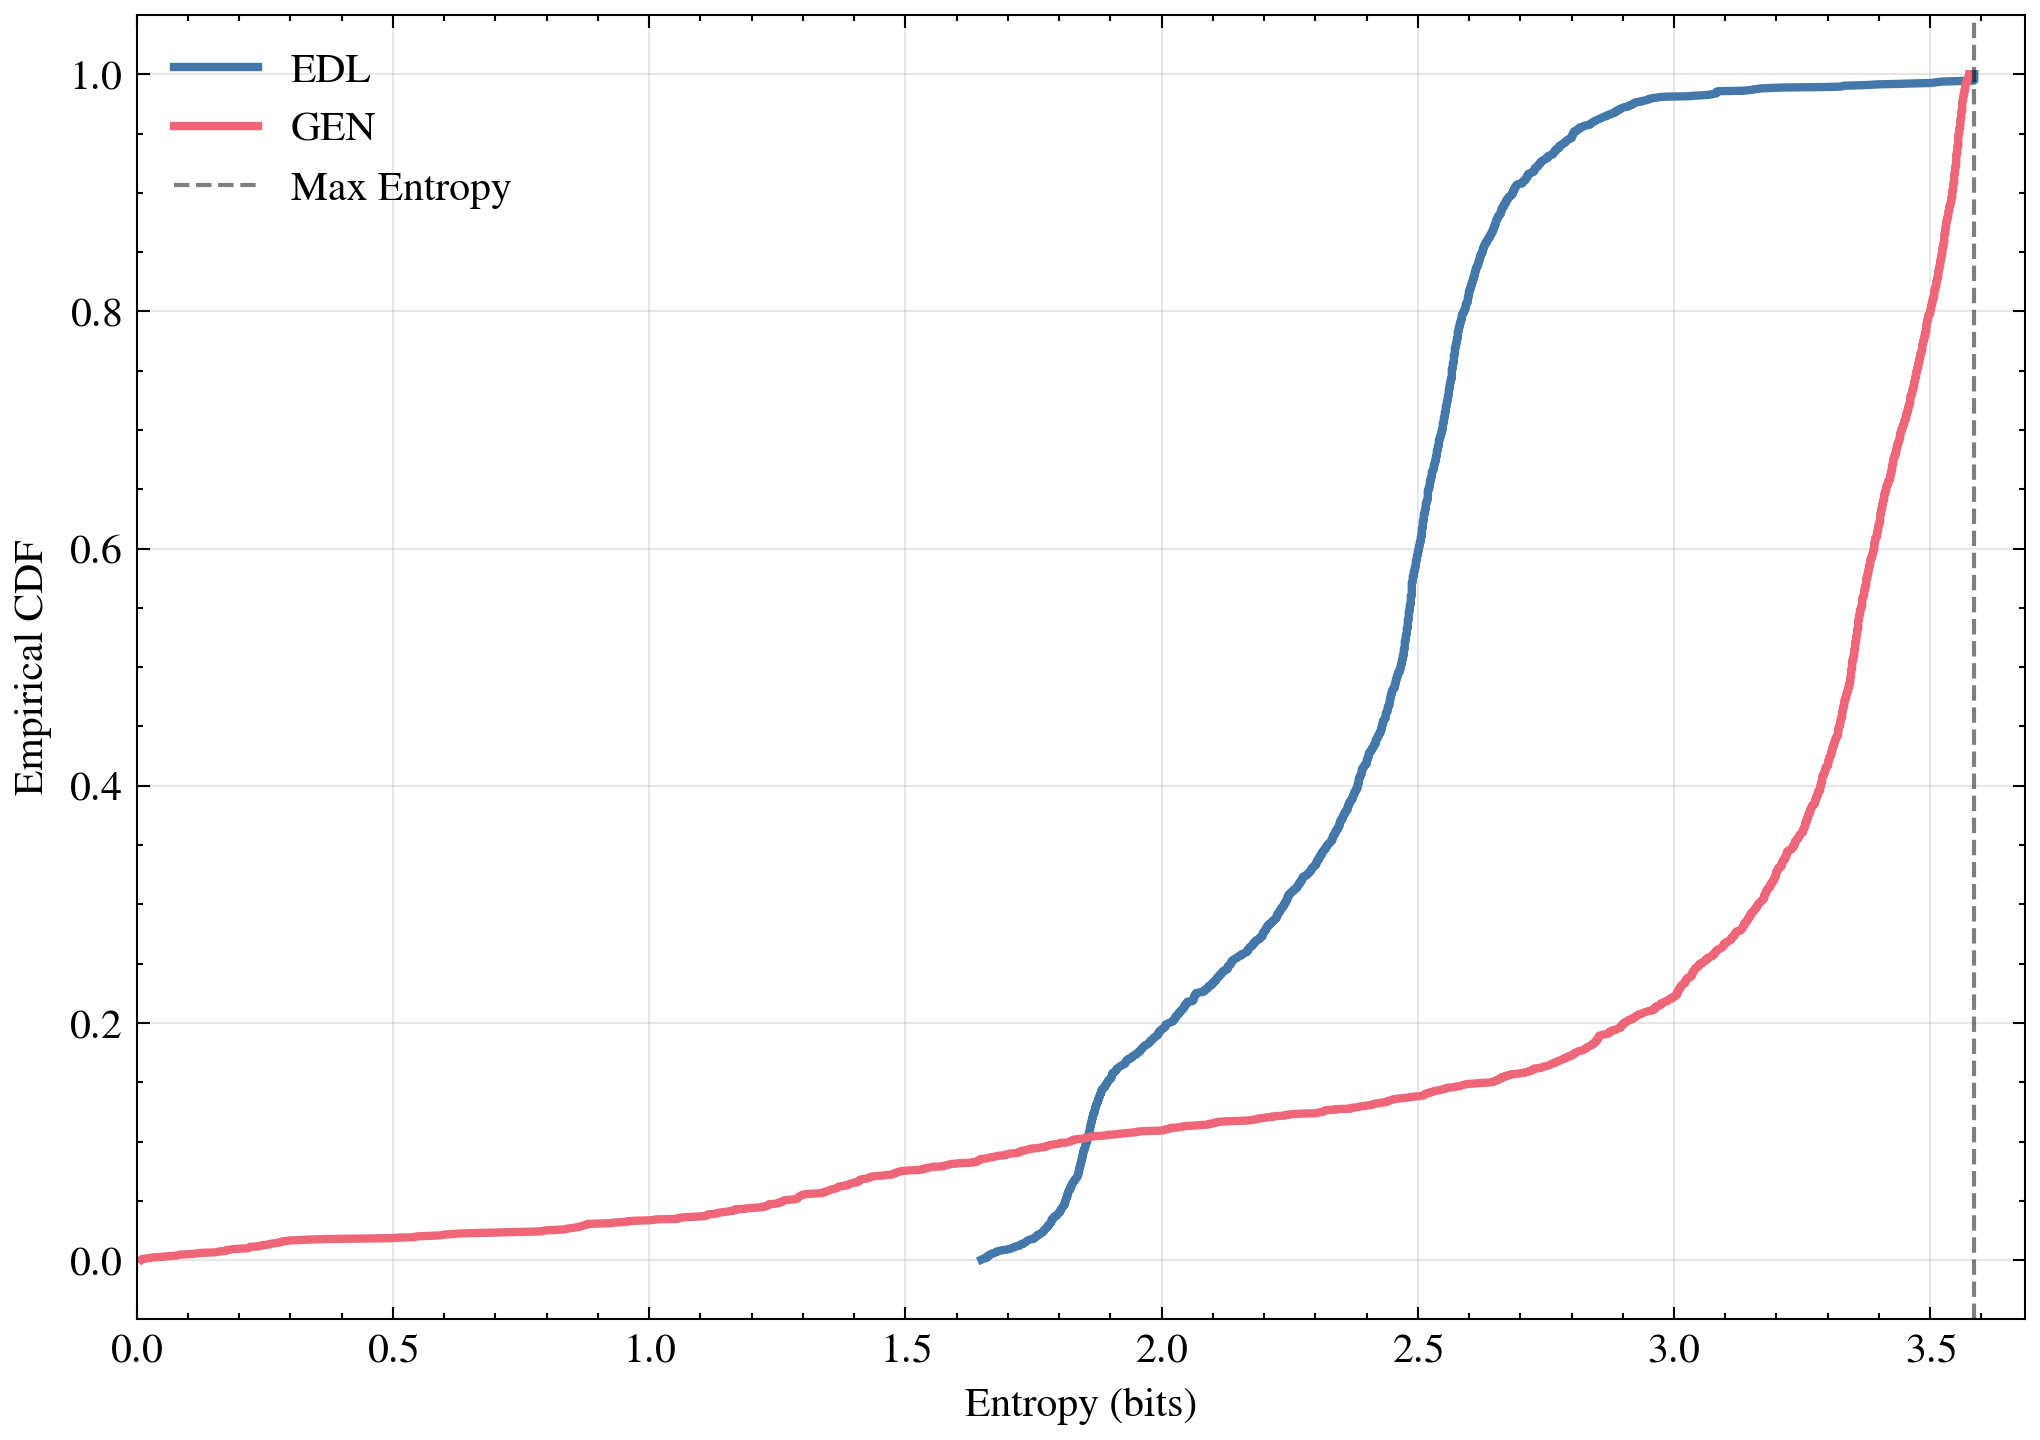

In [12]:
def _compute_ood_entropy(
    model: torch.nn.Module,
    inference_fn: Callable,
    ood_loader: torch.utils.data.DataLoader,
    device: torch.device,
) -> np.ndarray:
    model.eval()
    entropies = []

    with torch.no_grad():
        for x, _ in ood_loader:
            with torch.autocast(device_type=device.type, dtype=torch.float16):
                logits = model(x.to(device))

            # 1. Get Dirichlet probabilities (p = alpha / S)
            # Ensure your model/inference applies softplus/relu for evidence
            _, _, probs = inference_fn(logits)

            # 2. Compute Entropy: -sum(p * log(p))
            # Add epsilon to avoid log(0)
            eps = 1e-10
            entropy = -torch.sum(probs * torch.log2(probs + eps), dim=1)
            entropies.extend(entropy.cpu().numpy())

    return np.array(entropies)


# Collect entropies for both models
results = {
    "EDL": _compute_ood_entropy(edl_fusion, edl_inference, ood_dl, DEVICE),
    "GEN": _compute_ood_entropy(gen_fusion, gen_inference, ood_dl, DEVICE),
}
max_entropy = np.log2(settings.n_activities)

plt.figure(figsize=(7, 5))

for label, entropies in results.items():
    # Sort data for ECDF
    x = np.sort(entropies)
    y = np.arange(1, len(x) + 1) / len(x)

    plt.plot(x, y, label=label, lw=2)

plt.axvline(x=max_entropy, color="k", linestyle="--", alpha=0.5, label="Max Entropy")

plt.xlabel("Entropy (bits)")
plt.ylabel("Empirical CDF")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, max_entropy + 0.1)
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "edl_ood_entropy_cdf.pdf")
plt.show()